In [1]:
from datetime import datetime
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import matplotlib.pyplot as plt

#### Loading the Data

In [2]:
training_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)
print(training_data)
print(test_data)

100.0%
100.0%
100.0%
100.0%

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ../data
    Split: Test
    StandardTransform
Transform: ToTensor()


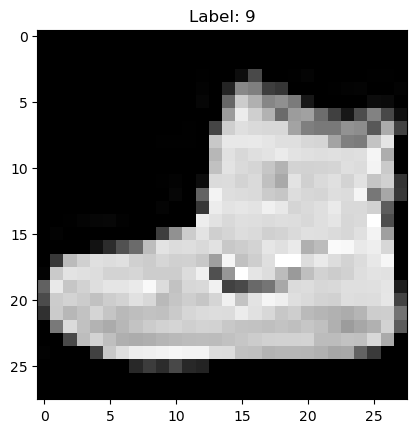

In [95]:
img, label = training_data[0]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

In [3]:
import math
def plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test):
    plt.figure(1)
    plt.plot(torch.arange(nepochs), cost_hist, "-", label='train')
    plt.plot(torch.arange(nepochs), cost_hist_test, "r-", label='test')
    mincost = max(max(cost_hist),1.0)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(0,mincost)
    plt.title("Cross-Entropy Cost")
    plt.legend()
    plt.figure(2)
    plt.plot(torch.arange(nepochs), acc_hist,"-", label='train')
    plt.plot(torch.arange(nepochs), acc_hist_test,"r-", label='test')
    minacc = min(min(acc_hist),0.8)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(minacc,1)
    plt.legend()
    plt.title("Accuracy")

#### CNN

In [62]:
class CNN2Layer3MLPLayer(torch.nn.Module):
    
    def __init__(self, nhidden1=240, nhidden2=80, noutput=10):
        super(CNN2Layer3MLPLayer, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            torch.nn.Flatten(),
            torch.nn.Linear(14*14*32, nhidden1),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden1, nhidden2),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden2, noutput)
        ) 
    
    def forward(self, x):
        z = self.layers(x)
        return z


In [63]:
model = CNN2Layer3MLPLayer()

In [64]:
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
            Conv2d-3           [-1, 32, 28, 28]           9,248
              ReLU-4           [-1, 32, 28, 28]               0
         MaxPool2d-5           [-1, 32, 14, 14]               0
           Flatten-6                 [-1, 6272]               0
            Linear-7                  [-1, 240]       1,505,520
              ReLU-8                  [-1, 240]               0
            Linear-9                   [-1, 80]          19,280
             ReLU-10                   [-1, 80]               0
           Linear-11                   [-1, 10]             810
Total params: 1,535,178
Trainable params: 1,535,178
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forw

#### GPU

In [65]:
device = None
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else: 
    device = torch.device("cpu")

print(device)

mps


In [66]:
def train_val(model, cost, epochs, train_loader, val_loader, optimizer, device):
    model = model.to(device)
    cost = cost.to(device)
    
    cost_hist = []
    cost_hist_test = []
    acc_hist = []
    acc_hist_test = []    
    train_samples = len(train_loader.dataset)
    val_samples = len(val_loader.dataset)
    train_batches = len(training_loader)
    val_batches = len(val_loader)
    for epoch in range(nepochs):
        cost, acc = 0.0, 0.0
        for batch, (X, Y) in enumerate(train_loader):
            X, Y = X.to(device), Y.to(device)
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
    
            # gradient, parameter update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        cost /= train_batches
        acc /= train_samples
    
        cost_val, acc_val = 0.0, 0.0
        with torch.no_grad():
            for batch, (X, Y) in enumerate(val_loader): 
                X, Y = X.to(device), Y.to(device)
                pred = model(X)
                cost_val += cost_ce(pred, Y).item()
                acc_val += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
            cost_val /= val_batches
            acc_val /= val_samples
        
        print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, cost_val, acc, acc_val))
        cost_hist.append(cost)
        cost_hist_test.append(cost_val)
        acc_hist.append(acc)
        acc_hist_test.append(acc_val)

    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

In [67]:
nbatch = 64
nepochs = 30
learning_rate = 0.04

model = CNN2Layer3MLPLayer()
cost_ce = torch.nn.CrossEntropyLoss()

train_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=nbatch, shuffle=False)

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

cost_hist, cost_hist_test, acc_hist, acc_hist_test = train_val(model, cost_ce, nepochs, train_loader, test_loader, optimizer, device)

Epoch 0: 0.780457, 0.543901, 0.708250, 0.789000
Epoch 1: 0.437304, 0.401387, 0.837333, 0.849600
Epoch 2: 0.356471, 0.372576, 0.869433, 0.864900
Epoch 3: 0.312952, 0.321969, 0.884200, 0.880700
Epoch 4: 0.284059, 0.299580, 0.895033, 0.887900
Epoch 5: 0.261555, 0.345385, 0.903283, 0.869700
Epoch 6: 0.244063, 0.295595, 0.909533, 0.890900
Epoch 7: 0.227372, 0.279909, 0.915733, 0.898200
Epoch 8: 0.212118, 0.261187, 0.920750, 0.905100
Epoch 9: 0.199005, 0.246989, 0.925700, 0.908700
Epoch 10: 0.187531, 0.272972, 0.930267, 0.902900
Epoch 11: 0.176933, 0.235733, 0.933700, 0.916300
Epoch 12: 0.166448, 0.253814, 0.937533, 0.909900
Epoch 13: 0.156603, 0.249914, 0.941350, 0.910800
Epoch 14: 0.146710, 0.257568, 0.945933, 0.909700
Epoch 15: 0.137571, 0.228968, 0.948417, 0.920200
Epoch 16: 0.128072, 0.250811, 0.952183, 0.917300
Epoch 17: 0.119376, 0.252856, 0.955667, 0.912000
Epoch 18: 0.111924, 0.250895, 0.958067, 0.917100
Epoch 19: 0.103627, 0.254006, 0.961350, 0.922600
Epoch 20: 0.095044, 0.252898, 

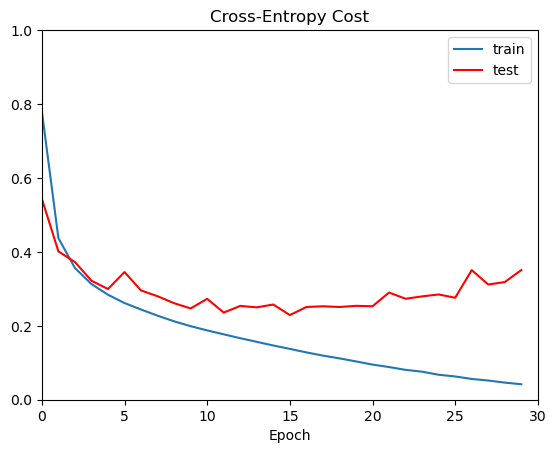

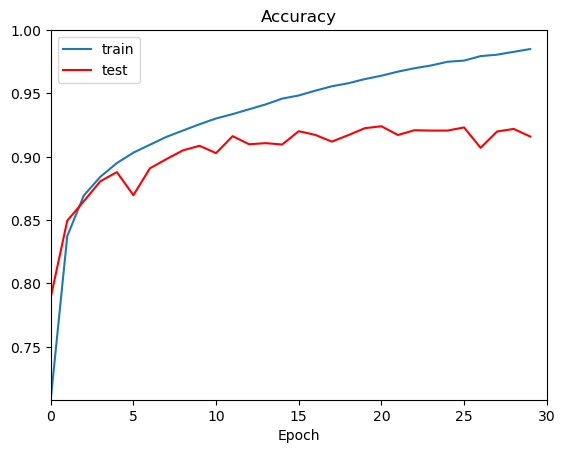

In [68]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test)

### Dropout

In [73]:
class CNN2Layer3MLPLayerDropout(torch.nn.Module):
    
    def __init__(self, nhidden1=240, nhidden2=80, dropout_rate=0.7, noutput=10):
        super(CNN2Layer3MLPLayerDropout, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            torch.nn.Flatten(),
            torch.nn.Dropout(p=dropout_rate),
            torch.nn.Linear(14*14*32, nhidden1),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout_rate),
            torch.nn.Linear(nhidden1, nhidden2),
            torch.nn.ReLU(),
            torch.nn.Dropout(p=dropout_rate),
            torch.nn.Linear(nhidden2, noutput)
        ) 
    
    def forward(self, x):
        z = self.layers(x)
        return z


In [74]:
summary(CNN2Layer3MLPLayerDropout(), (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
            Conv2d-3           [-1, 32, 28, 28]           9,248
              ReLU-4           [-1, 32, 28, 28]               0
         MaxPool2d-5           [-1, 32, 14, 14]               0
           Flatten-6                 [-1, 6272]               0
           Dropout-7                 [-1, 6272]               0
            Linear-8                  [-1, 240]       1,505,520
              ReLU-9                  [-1, 240]               0
          Dropout-10                  [-1, 240]               0
           Linear-11                   [-1, 80]          19,280
             ReLU-12                   [-1, 80]               0
          Dropout-13                   [-1, 80]               0
           Linear-14                   

In [75]:
nbatch = 64
nepochs = 30
learning_rate = 0.04

model = CNN2Layer3MLPLayerDropout()
cost_ce = torch.nn.CrossEntropyLoss()

train_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=nbatch, shuffle=False)

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

cost_hist_do, cost_hist_test_do, acc_hist_do, acc_hist_test_do = train_val(model, cost_ce, nepochs, train_loader, test_loader, optimizer, device)

Epoch 0: 1.310066, 0.917241, 0.481233, 0.637800
Epoch 1: 0.782203, 0.739822, 0.704400, 0.722900
Epoch 2: 0.669628, 0.662508, 0.755433, 0.761500
Epoch 3: 0.619985, 0.621299, 0.776333, 0.778900
Epoch 4: 0.584156, 0.579150, 0.791750, 0.798300
Epoch 5: 0.552279, 0.559695, 0.808233, 0.805900
Epoch 6: 0.525972, 0.551508, 0.819383, 0.811400
Epoch 7: 0.505353, 0.531607, 0.826367, 0.821800
Epoch 8: 0.488877, 0.500260, 0.833900, 0.831300
Epoch 9: 0.471432, 0.546938, 0.839267, 0.812100
Epoch 10: 0.457296, 0.471220, 0.844500, 0.840300
Epoch 11: 0.443796, 0.484881, 0.848783, 0.842200
Epoch 12: 0.432342, 0.459702, 0.852817, 0.845200
Epoch 13: 0.429344, 0.455674, 0.856383, 0.844000
Epoch 14: 0.417821, 0.457678, 0.857283, 0.849500
Epoch 15: 0.410597, 0.450669, 0.861350, 0.852300
Epoch 16: 0.405159, 0.446471, 0.861167, 0.852700
Epoch 17: 0.395168, 0.437811, 0.867133, 0.858000
Epoch 18: 0.391056, 0.422470, 0.866517, 0.859300
Epoch 19: 0.386253, 0.417107, 0.868933, 0.858800
Epoch 20: 0.380096, 0.435500, 

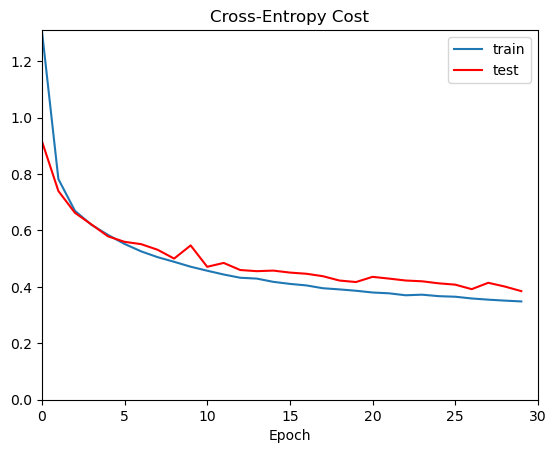

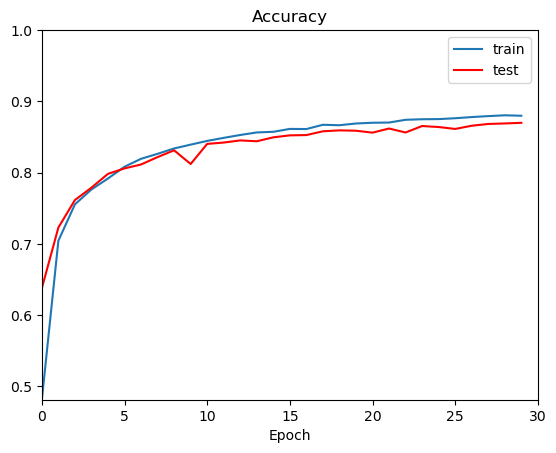

In [76]:
plot_training(nepochs, cost_hist_do, cost_hist_test_do, acc_hist_do, acc_hist_test_do)

In [82]:
def plot_two_runs(nepochs, cost_hist1, cost_hist_test1, cost_hist2, cost_hist_test2, title, low, high):
    epochs = torch.arange(nepochs)
    plt.plot(epochs, cost_hist1, "-", label='train 1')
    plt.plot(epochs, cost_hist_test1, "r-", label='test 1')
    plt.plot(epochs, cost_hist2, "--", label='train 2')
    plt.plot(epochs, cost_hist_test2, "r--", label='test 2')
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(low, high)
    plt.title(title)
    plt.legend()

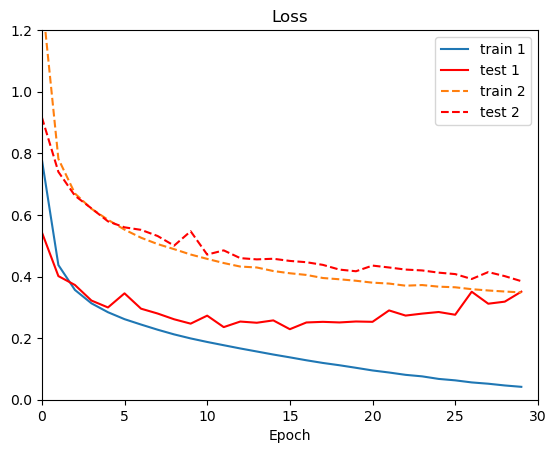

In [83]:
plot_two_runs(nepochs, cost_hist, cost_hist_test, cost_hist_do, cost_hist_test_do, "Loss", 0,1.2)

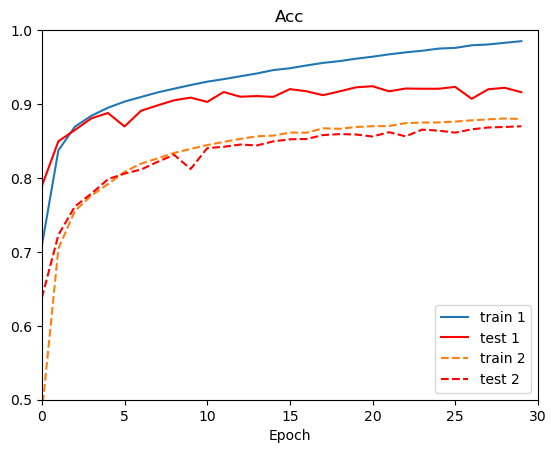

In [84]:
plot_two_runs(nepochs, acc_hist, acc_hist_test, acc_hist_do, acc_hist_test_do, "Acc", 0.5, 1.0)

### Data Augmentation

In [92]:
from torchvision.transforms import v2

transforms = v2.Compose([
    v2.RandomResizedCrop(size=(28, 28), scale = (0.7, 1.0)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToTensor(),
])

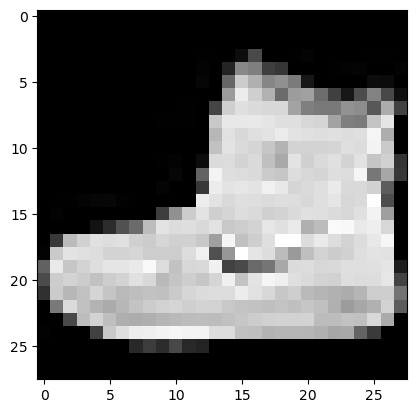

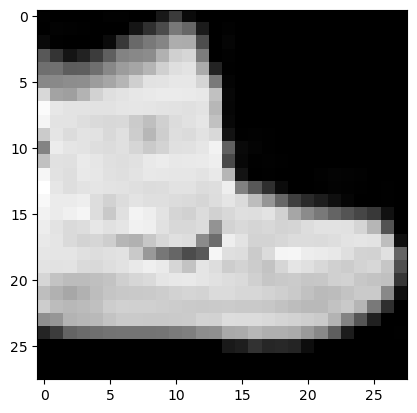

In [103]:
img, label = training_data[0]
img_trsf = transforms(img)
plt.figure(1)
plt.imshow(img.squeeze(), cmap="gray")
plt.figure(2)
plt.imshow(img_trsf.squeeze(), cmap="gray")
plt.show()

In [107]:
training_data_aug = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=transforms
)
test_data_aug = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

In [108]:
nbatch = 64
nepochs = 30
learning_rate = 0.04

model = CNN2Layer3MLPLayer()
cost_ce = torch.nn.CrossEntropyLoss()

train_loader_aug = DataLoader(training_data_aug, batch_size=nbatch, shuffle=True)
test_loader_aug = DataLoader(test_data_aug, batch_size=nbatch, shuffle=False)

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

cost_hist_aug, cost_hist_test_aug, acc_hist_aug, acc_hist_test_aug = train_val(model, cost_ce, nepochs, train_loader_aug, test_loader_aug, optimizer, device)

Epoch 0: 0.964569, 0.874941, 0.629950, 0.622300
Epoch 1: 0.621714, 0.514560, 0.756800, 0.808500
Epoch 2: 0.531716, 0.473289, 0.793650, 0.819700
Epoch 3: 0.482259, 0.438645, 0.816850, 0.829900
Epoch 4: 0.447179, 0.401254, 0.828800, 0.843800
Epoch 5: 0.421792, 0.366785, 0.839167, 0.866400
Epoch 6: 0.402599, 0.331051, 0.846917, 0.876100
Epoch 7: 0.389463, 0.335030, 0.850350, 0.880700
Epoch 8: 0.373668, 0.317630, 0.857783, 0.881600
Epoch 9: 0.362190, 0.307274, 0.861533, 0.885800
Epoch 10: 0.352755, 0.408025, 0.867083, 0.848500
Epoch 11: 0.343479, 0.324893, 0.869200, 0.873700
Epoch 12: 0.333129, 0.279949, 0.875200, 0.893900
Epoch 13: 0.326996, 0.424952, 0.877433, 0.846800
Epoch 14: 0.316680, 0.283228, 0.880100, 0.894800
Epoch 15: 0.311749, 0.281412, 0.882250, 0.896600
Epoch 16: 0.304022, 0.285324, 0.884317, 0.896000
Epoch 17: 0.302422, 0.271209, 0.885833, 0.900400
Epoch 18: 0.294509, 0.303311, 0.887950, 0.889900
Epoch 19: 0.291027, 0.278253, 0.889833, 0.900400
Epoch 20: 0.286274, 0.265221, 

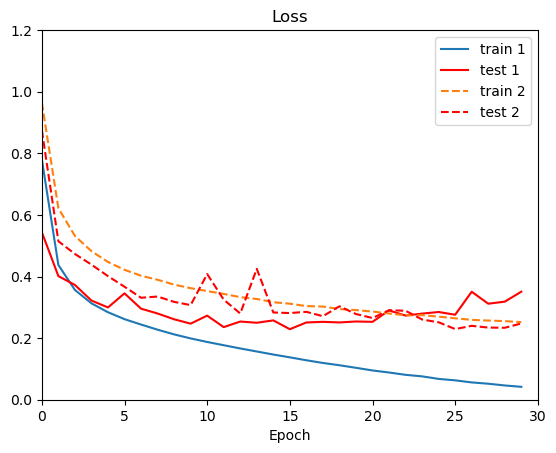

In [112]:
plot_two_runs(nepochs, cost_hist, cost_hist_test, cost_hist_aug, cost_hist_test_aug, "Loss", 0,1.2)

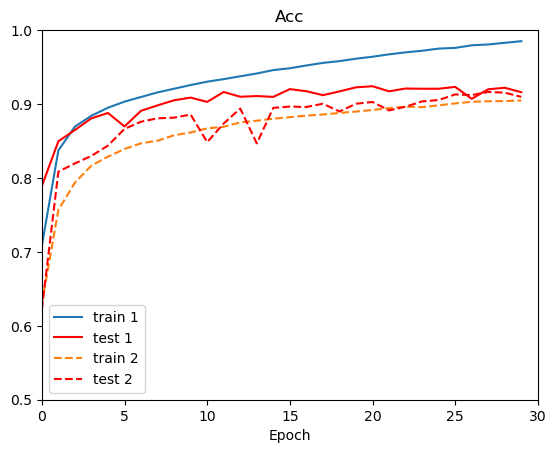

In [114]:
plot_two_runs(nepochs, acc_hist, acc_hist_test, acc_hist_aug, acc_hist_test_aug, "Acc", 0.5, 1.0)